### Final Project: Dataset

The telecom operator Interconnect would like to be able to forecast their churn of clients. If it's discovered that a user is planning to leave, they will be offered promotional codes and special plan options. Interconnect's marketing team has collected some of their clientele's personal data, including information about their plans and contract.

### Interconnect's Services

Interconnect mainly provides two types of services:
1. Landline communication. The telephone can be connected to several lines simultaneously.
2. Internet. The network can be set up via a telephone line (DSL, digital subscriber line) or through a fiber optic cable.

Some other services the company provides include:
-  Internet security: antivirus software (DeviceProtection) and a malicious website blocker (OnlineSecurity)
-  A dedicated technical support line (TechSupport)
-  Cloud file storage and data backup (OnlineBackup)
-  TV streaming (StreamingTV) and a movie directory (StreamingMovies)

The clients can choose either a monthly payment or sign a 1- or 2-year contract. They can use various payment methods and receive an electronic invoice after a transaction.

### Dataset and Data Description

The data is available for usage on the platform in the /datasets/final_provider/ folder.

The data consists of files obtained from different sources:
-  contract.csv — contract information
-  personal.csv — the client's personal data
-  internet.csv — information about Internet services
-  phone.csv — information about telephone services

In each file, the column customerID contains a unique code assigned to each client.

The contract information is valid as of February 1, 2020.

### Clarification: Summary

Target feature: the 'EndDate' column equals 'No'.

Primary metric: AUC-ROC.

Additional metric: Accuracy.

Assessment criteria:
-  AUC-ROC < 0.75 — 0 SP
-  0.75 ≤ AUC-ROC < 0.81 — 4 SP
-  0.81 ≤ AUC-ROC < 0.85 — 4.5 SP
-  0.85 ≤ AUC-ROC < 0.87 — 5 SP
-  0.87 ≤ AUC-ROC < 0.88 — 5.5 SP
-  AUC-ROC ≥ 0.88 — 6 SP

### Clarifying Questions
1. Which column is the target variable, and how is success defined?
2. Does the dataset contain missing values or incorrect data that require cleaning?
3. Are there categorical variables that need encoding or transformation?
4. Is this dataset time-based, requiring special train/test splitting?
5. Are there business constraints such as interpretability or processing speed?
6. How large is the dataset, and will it require sampling or optimization?

### Project Work Plan
The objective of this project is to build a classification model that predicts customer churn. Customers will be labeled as either active or cancelled, and the model will use historical data to identify patterns that indicate a high likelihood of cancellation.

### 1. Perform Data Preprocessing

- Examine the structure and content of all four datasets to understand what information they contain.  
- Check for duplicates, missing values, and incorrect or inconsistent data types.  
- Based on initial findings, determine the level of preprocessing required.  
- Remove duplicate records if present.  
- Handle missing values by either filling them with appropriate methods or removing them if they cannot be reasonably recovered.  
- Convert columns to proper data types for analysis (e.g., dates, numeric values, categorical variables).  
- If necessary, encode categorical variables for modeling purposes.  
- Combine all four datasets into a single unified dataframe to simplify analysis and modeling.

### 2. Perform Exploratory Data Analysis

- Visualize the data to better understand distributions and relationships.  
- Generate key plots such as histograms, boxplots, and correlation matrices.  
- Identify potential outliers and unusual patterns.  
- Investigate which features appear to have the strongest relationship with the target variable.  
- Evaluate class balance to determine whether the dataset is imbalanced.  
- If significant class imbalance exists, consider strategies such as adjusting decision thresholds or resampling techniques.

### 3. Train the Model

- Approach the problem as a supervised learning classification task.  
- Define the target variable as the “EndDate” column (indicating whether a customer has cancelled).  
- Perform a feature/target split.  
- Split the dataset into training, validation, and test sets using a 60/20/20 ratio.  
- Use AUC-ROC as the primary evaluation metric, with a minimum acceptable score of 0.75.  
- Test multiple models to compare performance, including:
  - Dummy baseline model  
  - Decision Tree  
  - Logistic Regression  
  - Random Forest  
  - CatBoost  
- Consider additional gradient boosting models such as LightGBM or XGBoost if earlier models do not perform well.

### 4. Test and Evaluate the Model

- Evaluate final model performance on the test set using AUC-ROC and accuracy.  
- Compare validation and test results to check for overfitting.  
- If necessary, perform additional hyperparameter tuning.  
- If the model performs poorly on the test set, consider adjusting the data split (for example, using a 70/15/15 split to increase training data).

### 5. Draw Conclusions

Final conclusions will be developed after the analysis is complete. The project will be considered successful when the following criteria are met:

- All code runs without errors and is arranged in logical order.  
- Clear documentation is provided explaining each step of the analysis.  
- The data has been properly downloaded, cleaned, and prepared.  
- Exploratory data analysis has been performed with appropriate visualizations.  
- Multiple models have been trained and evaluated.  
- A final predictive model has been produced with an AUC-ROC score of at least 0.75.

In [1]:
# imports
# general packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing packages
from datetime import datetime
from dateutil import relativedelta
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# model training packages
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

# optional additional models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# model evaluation packages
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    roc_curve
)

In [2]:
# data loading
df_contract = pd.read_csv('/datasets/final_provider/contract.csv')
df_personal = pd.read_csv('/datasets/final_provider/personal.csv')
df_internet = pd.read_csv('/datasets/final_provider/internet.csv')
df_phone = pd.read_csv('/datasets/final_provider/phone.csv')

# Preprocessing

In [3]:
# function to inspect data
def inspect_data(df, name="Dataset"):
    print(f"--- {name} Overview ---\n")
    
    print("Shape:")
    print(df.shape, "\n")
    
    print("Column Types:")
    print(df.dtypes, "\n")
    
    print("Missing Values:")
    print(df.isnull().sum(), "\n")
    
    print("Duplicate Rows:")
    print(df.duplicated().sum(), "\n")
    
    print("Basic Statistics (Numerical):")
    print(df.describe(), "\n")
    
    print("First 5 Rows:")
    display(df.head())

In [4]:
inspect_data(df_contract, "Contract Data")

--- Contract Data Overview ---

Shape:
(7043, 8) 

Column Types:
customerID           object
BeginDate            object
EndDate              object
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
dtype: object 

Missing Values:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64 

Duplicate Rows:
0 

Basic Statistics (Numerical):
       MonthlyCharges
count     7043.000000
mean        64.761692
std         30.090047
min         18.250000
25%         35.500000
50%         70.350000
75%         89.850000
max        118.750000 

First 5 Rows:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


No missing values or duplicated rows, but we need to convert some of our column's data types.  We have also identifed our target variable EndDate.

In [5]:
# column converions
df_contract['TotalCharges'] = pd.to_numeric(df_contract['TotalCharges'], errors='coerce')

# check for NaN created
df_contract['TotalCharges'].isnull().sum()

11

In [6]:
df_contract[df_contract['TotalCharges'].isnull()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,NaN


In [7]:
# These look like new customers without an initial charge so we will change these to 0.
df_contract['TotalCharges'] = df_contract['TotalCharges'].fillna(0)

In [8]:
df_contract.isnull().sum()

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [9]:
# Since we identified that 'EndDate' is our target variable, we need to create the Churn target variable from it.  
df_contract['Churn'] = df_contract['EndDate'].apply(lambda x: 0 if x == 'No' else 1)

# 1 means customer has churned, 0 means customer is still active.

In [10]:
# Fixed snapshot date (dataset reference date)
ref_date = pd.to_datetime('2020-02-01')

In [11]:
# converting dates into date-time
df_contract['BeginDate'] = pd.to_datetime(df_contract['BeginDate'], errors='coerce')
df_contract['EndDate'] = pd.to_datetime(df_contract['EndDate'], errors='coerce')

In [12]:
# Lets also calculate the timeframe the customer stayed so we can have a better prediction.
df_contract['TenureMonths'] = (
    (df_contract['EndDate'].fillna(ref_date) - df_contract['BeginDate'])
    .dt.days // 30
)

In [13]:
df_contract.sample(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureMonths
4317,5808-TOTXO,2019-11-01,NaT,One year,Yes,Credit card (automatic),20.55,57.40,0,3
4250,0565-JUPYD,2014-11-01,NaT,One year,No,Credit card (automatic),104.50,6590.80,0,63
6341,9330-IJWIO,2018-10-01,2019-11-01,Month-to-month,Yes,Electronic check,100.35,1358.85,1,13
6764,7660-HDPJV,2019-10-01,2019-11-01,Month-to-month,Yes,Electronic check,69.20,69.20,1,1
6761,2369-FEVNO,2020-01-01,NaT,Month-to-month,Yes,Mailed check,19.90,19.90,0,1
1137,0831-JNISG,2014-03-01,NaT,Two year,No,Mailed check,19.80,1396.25,0,72
6372,6368-TZZDT,2019-10-01,NaT,Two year,No,Credit card (automatic),19.50,96.85,0,4
6074,3797-VTIDR,2019-11-01,2019-12-01,Month-to-month,Yes,Electronic check,23.45,23.45,1,1
4909,3720-DBRWL,2015-11-01,NaT,Two year,Yes,Credit card (automatic),83.85,4307.10,0,51
4302,9134-WYRVP,2015-11-01,NaT,One year,No,Mailed check,86.35,4267.15,0,51


In [14]:
inspect_data(df_personal, "Personal Data")

--- Personal Data Overview ---

Shape:
(7043, 5) 

Column Types:
customerID       object
gender           object
SeniorCitizen     int64
Partner          object
Dependents       object
dtype: object 

Missing Values:
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64 

Duplicate Rows:
0 

Basic Statistics (Numerical):
       SeniorCitizen
count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000 

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


I did not notice anything out of the ordinary with this dataset in preprocessing.  We will proceed to encode categorical variables for ML algorithms.

In [15]:
# encoding categorical variables as binary: Yes and Male = 1, Female and No = 0
df_personal['Partner'] = df_personal['Partner'].map({'Yes': 1, 'No': 0})
df_personal['Dependents'] = df_personal['Dependents'].map({'Yes': 1, 'No': 0})
df_personal['gender'] = df_personal['gender'].map({'Male': 1, 'Female': 0})

In [16]:
df_personal.isnull().sum()

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

In [17]:
# running mean on binary values to check distribution
df_personal[['gender', 'SeniorCitizen', 'Partner', 'Dependents']].mean()

gender           0.504756
SeniorCitizen    0.162147
Partner          0.483033
Dependents       0.299588
dtype: float64

- We have about 50% split on genders male and female.
- We have about 16% seniors as customers.
- we have about 48% to 52% for having partners vs not.
- We have about 30% of customers with dependents.

In [18]:
inspect_data(df_internet, "Internet Data")

--- Internet Data Overview ---

Shape:
(5517, 8) 

Column Types:
customerID          object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
dtype: object 

Missing Values:
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64 

Duplicate Rows:
0 

Basic Statistics (Numerical):
        customerID InternetService OnlineSecurity OnlineBackup  \
count         5517            5517           5517         5517   
unique        5517               2              2            2   
top     2794-XIMMO     Fiber optic             No           No   
freq             1            3096           3498         3088   

       DeviceProtection TechSupport StreamingTV StreamingMovies  
count              5517        5517        5517  

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Object types and other preprocessing looks solid with the Internet dataset.  I could encode now but comparing the amount the count of rows, not all customers have internet.  I will encode after merging when I inspect all 4 datasets to maintain that distinction.

In [19]:
inspect_data(df_phone, "Phone Data")

--- Phone Data Overview ---

Shape:
(6361, 2) 

Column Types:
customerID       object
MultipleLines    object
dtype: object 

Missing Values:
customerID       0
MultipleLines    0
dtype: int64 

Duplicate Rows:
0 

Basic Statistics (Numerical):
        customerID MultipleLines
count         6361          6361
unique        6361             2
top     8642-GVWRF            No
freq             1          3390 

First 5 Rows:


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


We can see that like Internet, there is a smaller count compared to the Contract and Personal Data which indicates that some customers don't have phone service.  I will proceed the same way as I did with Internet and will encode after the merge.

Now that all 4 datasets have been inspected and finished preprocessing, lets merge them all on "customerID" since that is the common unique ID for all the datasets.  We will run left merge with contracts dataset as our main pillar because it has all the customers.

In [20]:
# Merging
df = df_contract.merge(df_personal, on='customerID', how='left')
df = df.merge(df_internet, on='customerID', how='left')
df = df.merge(df_phone, on='customerID', how='left')

In [21]:
print("Final shape:", df.shape)

Final shape: (7043, 22)


In [22]:
inspect_data(df, "Total Data")

--- Total Data Overview ---

Shape:
(7043, 22) 

Column Types:
customerID                  object
BeginDate           datetime64[ns]
EndDate             datetime64[ns]
Type                        object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
Churn                        int64
TenureMonths                 int64
gender                       int64
SeniorCitizen                int64
Partner                      int64
Dependents                   int64
InternetService             object
OnlineSecurity              object
OnlineBackup                object
DeviceProtection            object
TechSupport                 object
StreamingTV                 object
StreamingMovies             object
MultipleLines               object
dtype: object 

Missing Values:
customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMet

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureMonths,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,...,1,0,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,0,34,...,0,0,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,...,0,0,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,0,45,...,0,0,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,1,2,...,0,0,Fiber optic,No,No,No,No,No,No,No


We did not lose any customers during the merge which means we merged successfully and correctly.  We can see that 1526 customers do not have internet, lets change those column values to be more meaningful.  Then we will do the same for customers with no phone service.

In [23]:
# addressing customers with no internet
internet_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_cols:
    df[col] = df[col].fillna('No Internet')

In [24]:
# addressing customers with no phone
df['MultipleLines'] = df['MultipleLines'].fillna('No Phone')

In [25]:
df.isnull().sum()

customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
TenureMonths           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
MultipleLines          0
dtype: int64

In [26]:
df.sample(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureMonths,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
6494,4310-KEDTB,2017-12-01,NaT,Month-to-month,Yes,Mailed check,29.80,786.50,0,26,...,0,1,DSL,No,No,Yes,No,No,No,No Phone
2227,0788-DXBFY,2015-04-01,NaT,One year,Yes,Electronic check,19.55,1108.80,0,58,...,1,1,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No
5639,6490-FGZAT,2019-08-01,NaT,Month-to-month,No,Mailed check,20.65,109.30,0,6,...,0,0,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No
386,0533-BNWKF,2015-05-01,2019-12-01,Month-to-month,Yes,Electronic check,85.45,4874.70,1,55,...,1,0,Fiber optic,No,Yes,Yes,No,No,No,Yes
5431,5995-WWKKG,2017-01-01,NaT,One year,Yes,Electronic check,19.80,695.05,0,37,...,0,0,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No
5372,2786-GCDPI,2015-12-01,NaT,Month-to-month,Yes,Electronic check,104.95,5222.35,0,50,...,0,0,Fiber optic,No,No,Yes,Yes,Yes,Yes,Yes
3909,1093-YSWCA,2019-03-01,NaT,Two year,No,Credit card (automatic),19.55,223.15,0,11,...,0,0,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No
684,8040-MNRTF,2020-01-01,NaT,Month-to-month,No,Mailed check,71.10,71.10,0,1,...,0,0,Fiber optic,No,No,No,No,No,No,No
6630,1226-IENZN,2018-10-01,NaT,Month-to-month,Yes,Electronic check,78.75,1218.25,0,16,...,0,0,Fiber optic,No,No,No,No,No,Yes,No
2651,4873-ILOLJ,2017-11-01,2019-11-01,Month-to-month,Yes,Electronic check,90.35,2238.50,1,24,...,0,0,Fiber optic,No,No,No,No,Yes,Yes,No


In [27]:
df['Churn'].value_counts(normalize=True)

0    0.73463
1    0.26537
Name: Churn, dtype: float64

We can see some imbalancing here which means using only accuracy as a metric is not sufficient, we will be evaluating models using other metrics like AUC-ROC, F1-score, and Precision.

Let us proceed to clean up the dataset now that everything has been merged to a grand dataset by dropping some columns that aren't necessary anymore.

In [28]:
# dropping unnecessary columns
df = df.drop(['customerID', 'BeginDate', 'EndDate'], axis=1)

In [29]:
df.sample(10)

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureMonths,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
1657,Month-to-month,Yes,Electronic check,25.60,901.25,0,35,1,0,0,0,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,Yes
4073,Month-to-month,Yes,Electronic check,65.45,937.60,1,14,1,0,1,1,DSL,Yes,Yes,No,No,Yes,No,No
2280,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,8,0,1,0,0,Fiber optic,No,No,No,Yes,Yes,Yes,Yes
2165,One year,No,Mailed check,20.20,273.25,0,13,0,0,0,0,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No
1380,One year,Yes,Bank transfer (automatic),98.45,6145.20,0,61,1,0,1,1,Fiber optic,No,Yes,No,Yes,Yes,Yes,No
454,Two year,No,Mailed check,24.40,1417.90,0,61,0,0,1,0,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,No Internet,Yes
1115,Two year,Yes,Credit card (automatic),53.85,2200.70,0,39,1,0,0,0,DSL,No,No,No,Yes,No,No,Yes
4231,Two year,No,Bank transfer (automatic),80.60,5708.20,0,72,1,0,0,0,DSL,Yes,Yes,Yes,Yes,No,Yes,Yes
4496,Two year,No,Credit card (automatic),89.75,6595.90,0,73,0,0,1,1,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes
5257,Month-to-month,Yes,Electronic check,101.10,3744.05,1,37,1,1,0,0,Fiber optic,No,No,Yes,No,Yes,Yes,Yes


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              7043 non-null   object 
 1   PaperlessBilling  7043 non-null   object 
 2   PaymentMethod     7043 non-null   object 
 3   MonthlyCharges    7043 non-null   float64
 4   TotalCharges      7043 non-null   float64
 5   Churn             7043 non-null   int64  
 6   TenureMonths      7043 non-null   int64  
 7   gender            7043 non-null   int64  
 8   SeniorCitizen     7043 non-null   int64  
 9   Partner           7043 non-null   int64  
 10  Dependents        7043 non-null   int64  
 11  InternetService   7043 non-null   object 
 12  OnlineSecurity    7043 non-null   object 
 13  OnlineBackup      7043 non-null   object 
 14  DeviceProtection  7043 non-null   object 
 15  TechSupport       7043 non-null   object 
 16  StreamingTV       7043 non-null   object 


We handled the preprocessing of the datasets and merged them accordingly.  We will move on to EDA to start visualizing the data and handle changes accordingly.

# Exploratory Data Analysis (EDA)

## Numerical Feature EDA

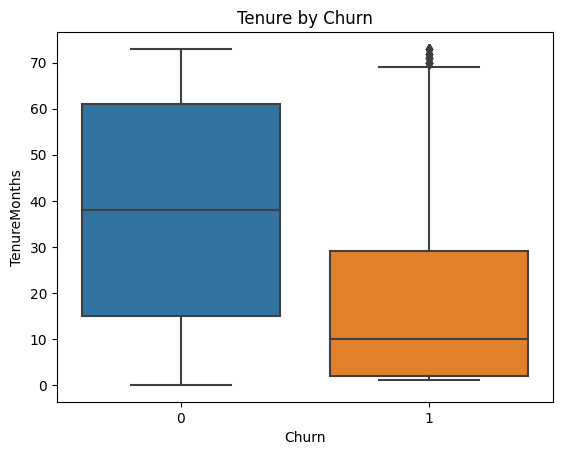

In [31]:
# plot to compare tenure by churn, 0 = active, 1 = churned
sns.boxplot(x='Churn', y='TenureMonths', data=df)
plt.title("Tenure by Churn")
plt.show()

The boxplot reveals that churned customers generally have much shorter tenures than non-churned customers. This indicates that tenure is strongly associated with churn and will likely be an important predictor in the final model.

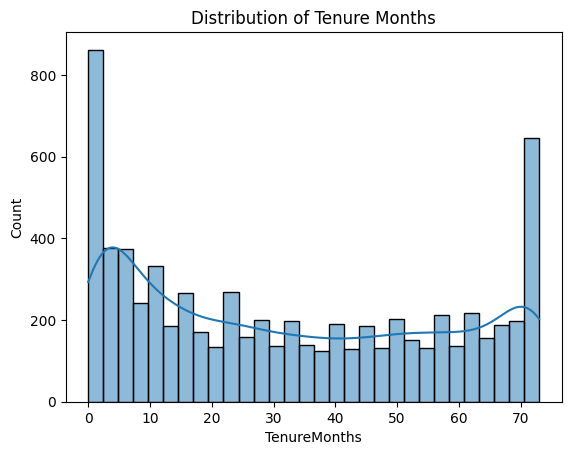

In [32]:
sns.histplot(df['TenureMonths'], bins=30, kde=True)
plt.title("Distribution of Tenure Months")
plt.show()

The distribution of TenureMonths is right-skewed, with most customers having short tenures. This suggests that newer customers make up a large share of the dataset and are more prone to churn.

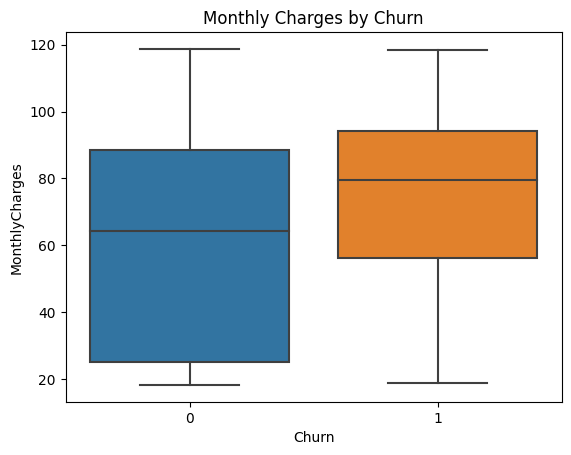

In [33]:
# plot to show monthly charge amounts, 0 = active, 1 = churned
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

The boxplot of MonthlyCharges shows that churned customers tend to have higher monthly charges than those who remain active. The median monthly charge for churned customers is noticeably higher, and their overall charge distribution is shifted upward. This suggests that customers paying more each month are more likely to cancel their service.

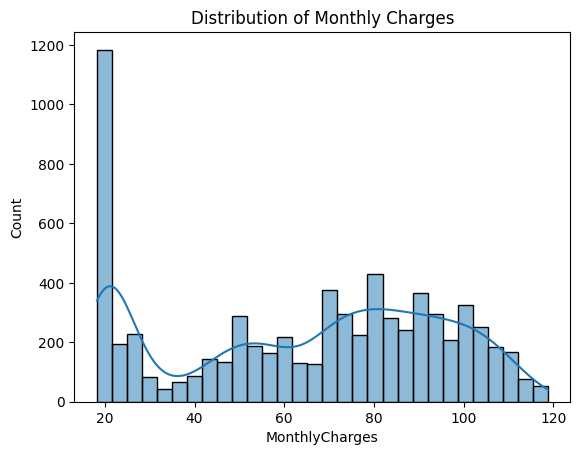

In [34]:
# plot to show distribution of monthly charges across customers.
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

Monthly charges are broadly distributed across a wide range of values, with several peaks that reflect different pricing tiers. This variation suggests that customers subscribe to a diverse set of service plans with differing costs.

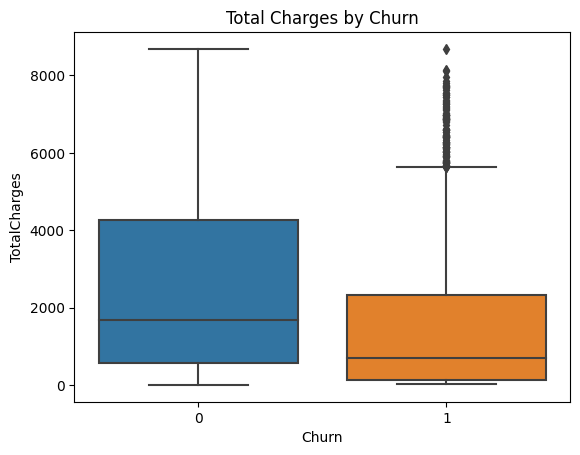

In [35]:
# plot for accumulated charges for customers, 0 = active, 1 = churned
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges by Churn")
plt.show()

Churned customers generally show much lower total charges than active customers, indicating that customers who leave typically have shorter relationships with the company.

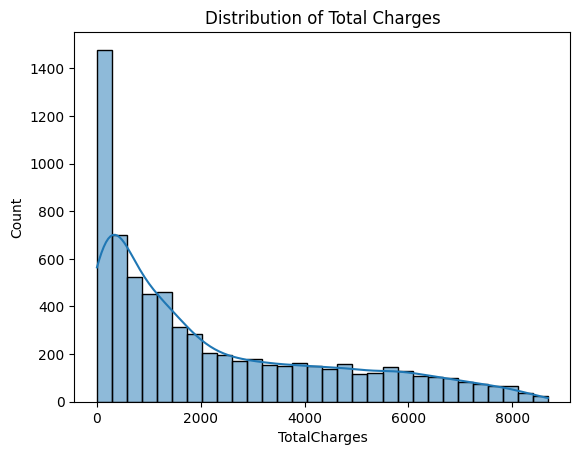

In [36]:
# plot to show distribution of total charges across customers
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title("Distribution of Total Charges")
plt.show()

Total charges are highly right-skewed, with most customers having low accumulated charges and only a small number reaching very high totals. This reflects the large number of relatively new customers in the dataset.

## Categorical Feature EDA


In [37]:
# make churn legends nicer to look at
def fix_churn_legend(ax):
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title("Churn")
        for t in leg.get_texts():
            if t.get_text() == "0":
                t.set_text("Active (0)")
            elif t.get_text() == "1":
                t.set_text("Churned (1)")

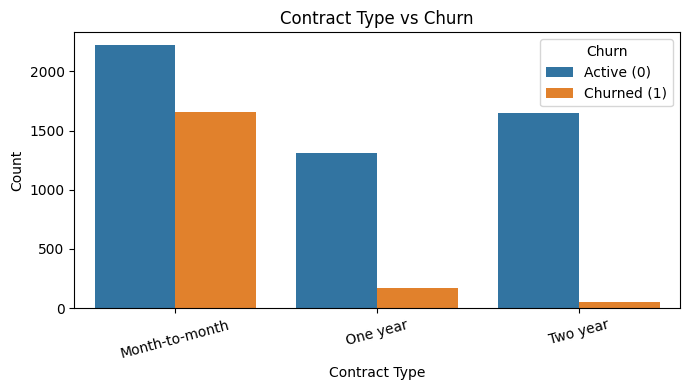

In [38]:
# Contract type plot
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df, x='Type', hue='Churn')
ax.set_title("Contract Type vs Churn")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Count")
fix_churn_legend(ax)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The contract type shows a strong relationship with churn. Customers on month-to-month contracts churn at a much higher rate than those on one-year or two-year contracts. Long-term contracts appear to significantly reduce churn risk, likely because they encourage customer commitment and stability.

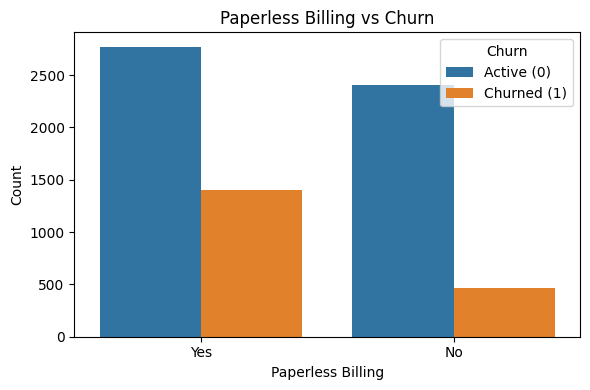

In [39]:
# paperless billing comparison chart
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
ax.set_title("Paperless Billing vs Churn")
ax.set_xlabel("Paperless Billing")
ax.set_ylabel("Count")
fix_churn_legend(ax)
plt.tight_layout()
plt.show()

Customers who use paperless billing show a noticeably higher churn rate compared to those who do not. This may indicate that customers who manage their accounts more actively online are also more likely to switch providers when dissatisfied.

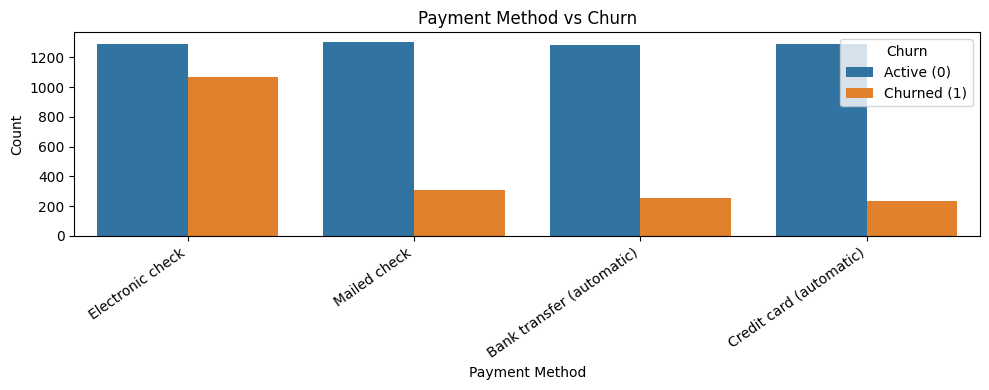

In [40]:
# payment method comparison chart
plt.figure(figsize=(10,4))
ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn')
ax.set_title("Payment Method vs Churn")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Count")
fix_churn_legend(ax)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Payment method appears to be an important factor in churn. Customers who pay by electronic check have the highest churn rate, while those using automatic payment methods such as bank transfer or credit card show much lower churn. This suggests that convenience and automation in billing may improve customer retention.

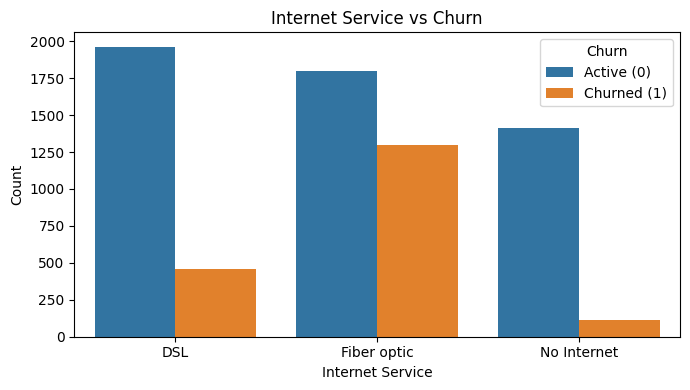

In [41]:
# Internet service comparison chart
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df, x='InternetService', hue='Churn')
ax.set_title("Internet Service vs Churn")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Count")
fix_churn_legend(ax)
plt.tight_layout()
plt.show()

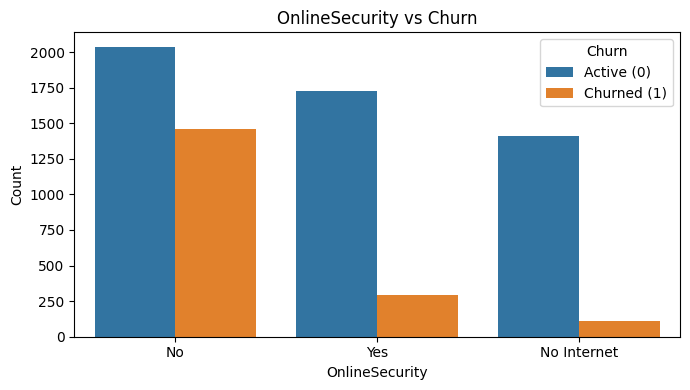

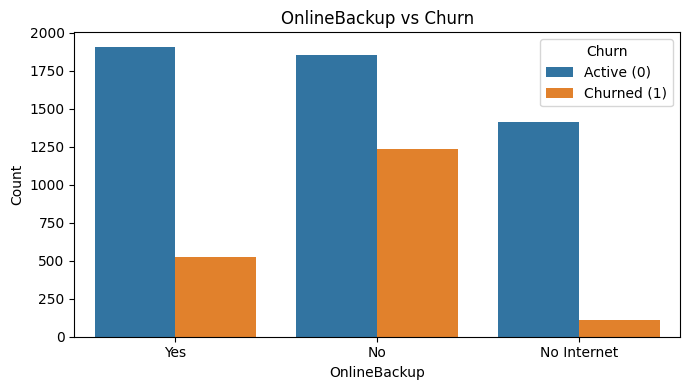

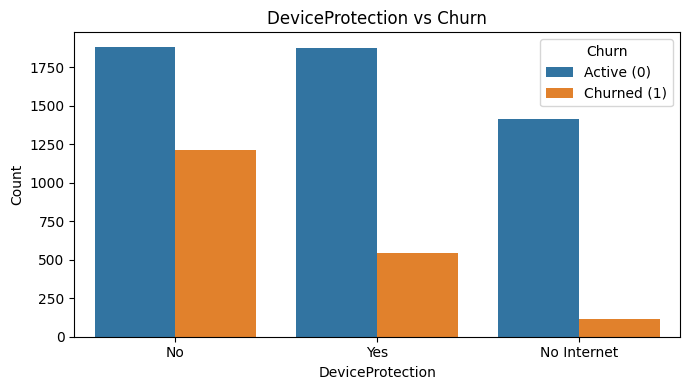

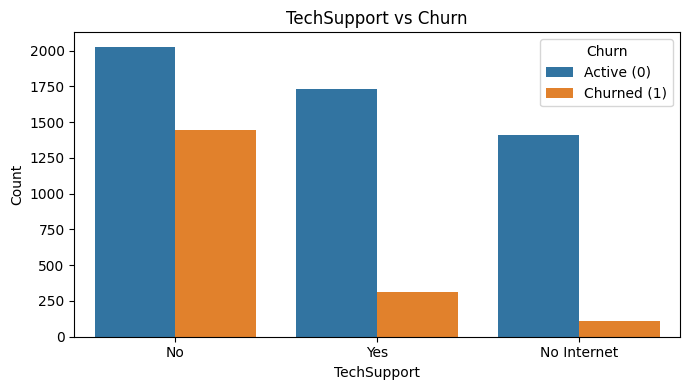

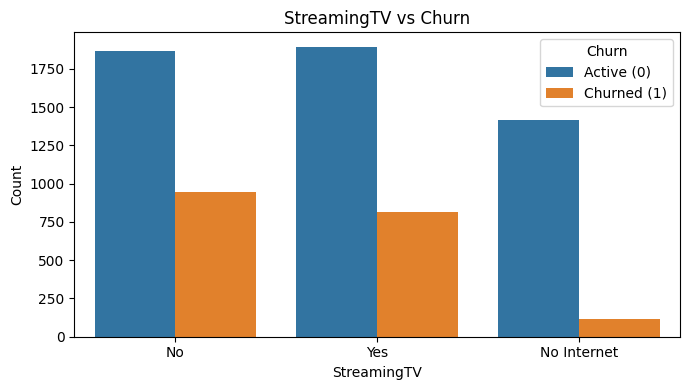

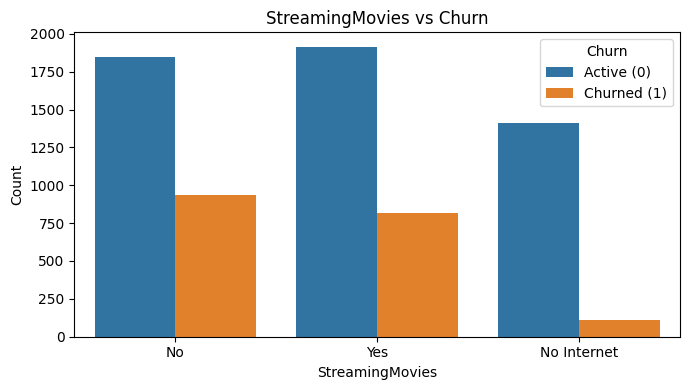

In [42]:
# internet add-on features comparison chart
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in addon_cols:
    plt.figure(figsize=(7,4))
    ax = sns.countplot(data=df, x=col, hue='Churn')
    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    fix_churn_legend(ax)
    plt.tight_layout()
    plt.show()

Across most internet-related services, a clear pattern emerges: customers who lack additional services such as online security, tech support, or device protection tend to churn more frequently. In particular, the absence of tech support and online security is strongly associated with higher churn. This suggests that customers who purchase more comprehensive service packages are more likely to remain loyal.

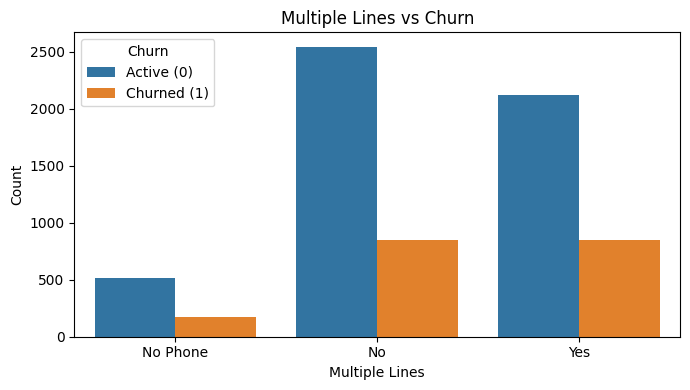

In [43]:
# phone service comparison chart
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df, x='MultipleLines', hue='Churn')
ax.set_title("Multiple Lines vs Churn")
ax.set_xlabel("Multiple Lines")
ax.set_ylabel("Count")
fix_churn_legend(ax)
plt.tight_layout()
plt.show()

Customers without multiple phone lines show slightly higher churn compared to those with multiple lines. This may indicate that customers who rely more heavily on phone services are more engaged and therefore less likely to leave.

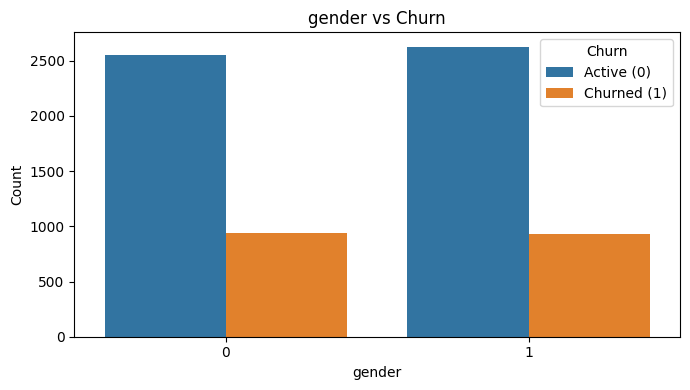

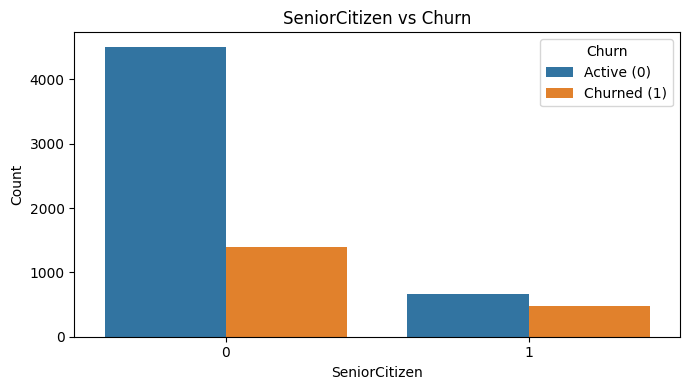

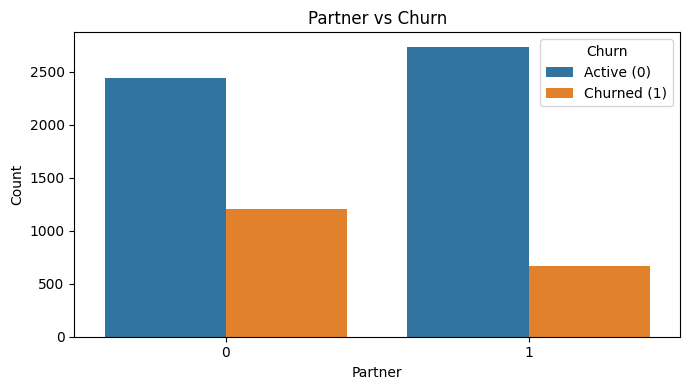

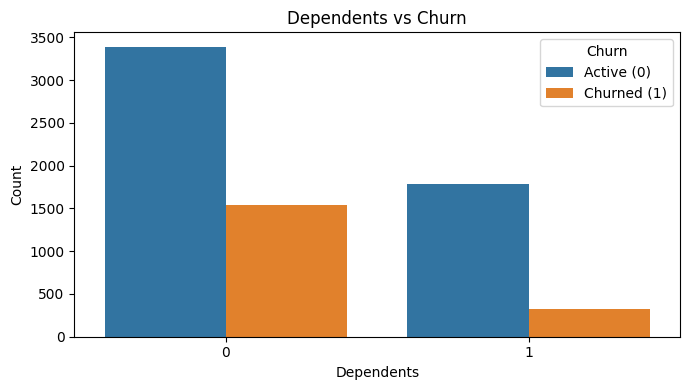

In [44]:
# demographics comparison chart
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
for col in demo_cols:
    plt.figure(figsize=(7,4))
    ax = sns.countplot(data=df, x=col, hue='Churn')
    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    fix_churn_legend(ax)
    plt.tight_layout()
    plt.show()

Demographic factors such as gender, partner status, dependents, and senior citizen status show weaker relationships with churn compared to service-related features. However, senior citizens appear to churn at a somewhat higher rate, and customers without partners or dependents are slightly more likely to cancel. Overall, behavioral and service usage factors appear to be more important than demographics.

The categorical analysis highlights several key drivers of churn. Contract type and payment method are among the strongest indicators, with month-to-month contracts and electronic check payments showing the highest churn rates. Lack of additional services such as tech support and online security is also strongly associated with cancellation. Demographic variables, while somewhat relevant, appear to play a smaller role compared to service-related features.

Now that we are essentially done with EDA, we are ready to move on to modeling and training.  Let's take a look at the clarifying questions we formulated and see if they are answered.

## Clarifying Questions Check

1. **Target Variable:**  
   The target variable is `Churn`, derived from the `EndDate` column. Success will be evaluated using metrics such as AUC-ROC, precision, recall, and F1-score.

2. **Missing Values and Data Cleaning:**  
   Initial issues were found in the `TotalCharges` column and date fields, which were corrected. After merging datasets, missing values related to internet and phone services were filled with appropriate categories. The final dataset contains no missing values.

3. **Categorical Variables:**  
   Yes, several categorical variables exist and will require encoding before modeling, including contract type, payment method, and service-related features.

4. **Time-Based Considerations:**  
   Although the dataset contains date information, the task is not a time-series forecasting problem. A standard stratified train/test split will be appropriate.

5. **Business Constraints:**  
   Interpretability is important for this problem, as the goal is to understand churn drivers. Processing speed is not a major constraint due to the relatively small dataset size.

6. **Dataset Size:**  
   The dataset contains 7,043 rows, which is manageable without the need for sampling or specialized optimization techniques.


# Model Training and Evaluation
In this section, multiple supervised learning models are trained and evaluated to predict customer churn.  All data preprocessing and exploratory data analysis steps were completed.

In [45]:
# Defining features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(X.shape, y.shape)

(7043, 18) (7043,)


The target variable for this task is `Churn`, which indicates whether a customer has cancelled their service.  All remaining columns are used as input features for model training.

### Train, Validation, and Test Split

The dataset is split into training, validation, and test sets using a 60/20/20 ratio.  
Stratified sampling is applied to preserve the original churn distribution across all splits.  

- The training set is used to fit the models  
- The validation set is used for model comparison and selection  
- The test set is used only once for final evaluation


In [46]:
# 60 / 20 / 20 split with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=12345
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=12345
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (4225, 18)
Validation: (1409, 18)
Test: (1409, 18)


Categorical variables are encoded using one-hot encoding, while numerical features are scaled.  A preprocessing pipeline is used to prevent data leakage and ensure consistent transformations.

In [47]:
# Encoding columns
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)    

In [48]:
# function to evaluate models
def evaluate_model(model, name, threshold=0.5):
    """
    Trains the model, evaluates on validation data,
    prints metrics, plots ROC curve and confusion matrix.
    """
    # Fit model
    model.fit(X_train, y_train)

    # Probabilities and predictions
    probs = model.predict_proba(X_valid)[:, 1]
    preds = (probs >= threshold).astype(int)

    # Metrics
    auc = roc_auc_score(y_valid, probs)
    acc = accuracy_score(y_valid, preds)
    f1 = f1_score(y_valid, preds)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"AUC-ROC : {auc:.3f}")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score: {f1:.3f}")

    # --- ROC Curve (compatible version) ---
    fpr, tpr, _ = roc_curve(y_valid, probs)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_valid, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Active', 'Churned'],
        yticklabels=['Active', 'Churned']
    )
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "auc": auc,
        "accuracy": acc,
        "f1": f1
    }

## Training and Validation Set Evaluation

### Baseline Model
A dummy classifier is used as a baseline to establish a minimum performance benchmark.



Dummy Classifier
----------------
AUC-ROC : 0.500
Accuracy: 0.735
F1-score: 0.000


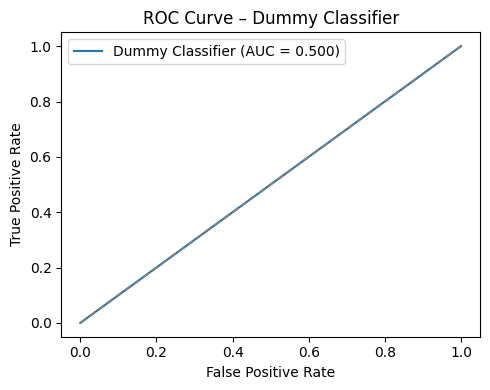

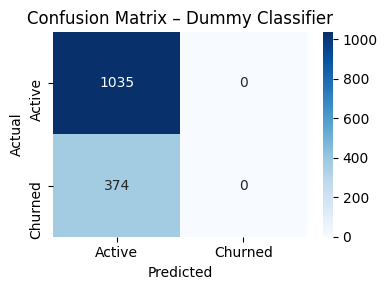

In [49]:
# Dummy model
dummy = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

dummy_results = evaluate_model(dummy, "Dummy Classifier")

The dummy classifier predicts the most frequent class (non-churn) for all observations. As expected, it achieves an accuracy of approximately 73.5%, which reflects the underlying class distribution rather than true predictive power. However, its AUC-ROC of 0.50 and F1-score of 0.00 indicate that the model has no ability to distinguish between churned and non-churned customers. This confirms that accuracy alone is not an appropriate metric for this task and establishes a meaningful baseline for comparison with more advanced models.


### Logistic Regression


Logistic Regression
-------------------
AUC-ROC : 0.836
Accuracy: 0.798
F1-score: 0.602


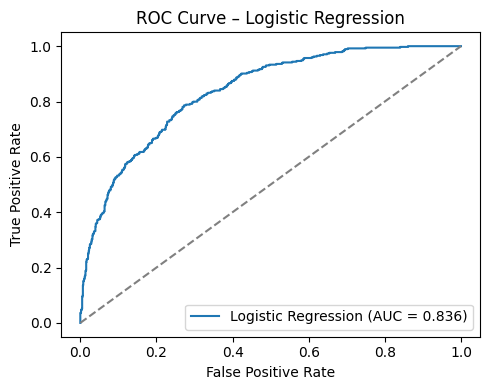

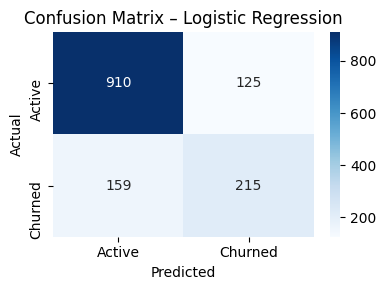

In [50]:
log_reg = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(random_state = 12345, solver = 'liblinear'))
])

lr_results = evaluate_model(log_reg, "Logistic Regression")

Logistic regression demonstrates strong predictive performance on the validation set, achieving an AUC-ROC of 0.836, accuracy of 0.798, and an F1-score of 0.602. The ROC curve shows good separation between churned and non-churned customers, indicating that the model is able to rank churn risk effectively. The confusion matrix reveals a reasonable balance between correctly identifying churned customers and minimizing false positives, though some churned customers are still misclassified. Overall, these results suggest that a linear model captures a substantial portion of the churn signal, while leaving room for potential improvement from more flexible models.

### Decision Tree


Decision Tree
-------------
AUC-ROC : 0.657
Accuracy: 0.722
F1-score: 0.497


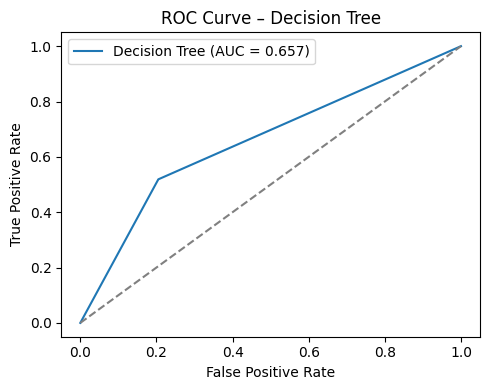

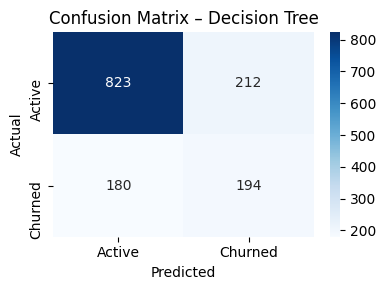

In [51]:
dt = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(random_state=12345))
])

dt_results = evaluate_model(dt, "Decision Tree")

The decision tree classifier shows noticeably weaker performance on the validation set, with an AUC-ROC of 0.657, accuracy of 0.722, and an F1-score of 0.497. The ROC curve indicates limited ability to distinguish between churned and non-churned customers, and the confusion matrix reveals a relatively high number of misclassifications, particularly false negatives among churned customers. These results suggest that the unconstrained decision tree struggles to generalize effectively and may be overfitting to patterns in the training data, making it less suitable than other models for this task.


### Random Forest


Random Forest
-------------
AUC-ROC : 0.817
Accuracy: 0.791
F1-score: 0.571


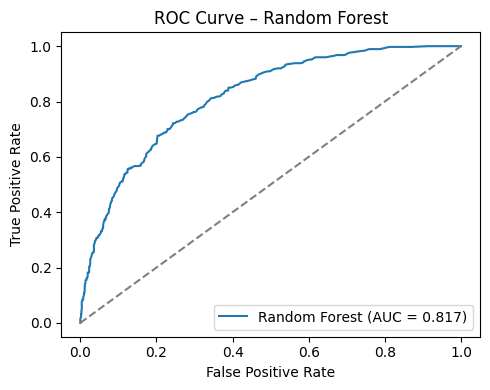

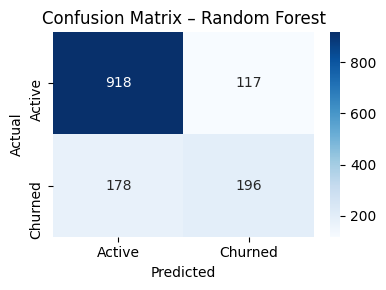

In [52]:
rf = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=12345,
        n_jobs=-1
    ))
])

rf_results = evaluate_model(rf, "Random Forest")

The random forest classifier demonstrates solid predictive performance on the validation set, achieving an AUC-ROC of 0.817, accuracy of 0.791, and an F1-score of 0.571. The ROC curve shows good class separation, indicating avoidance of severe overfitting compared to a single decision tree. However, the confusion matrix reveals a notable number of false negatives among churned customers, suggesting that while the ensemble improves stability and ranking performance, it does not substantially outperform logistic regression in identifying churners. Overall, random forest offers a more robust alternative to a single decision tree but does not provide a clear advantage over simpler models in this setting.

### CatBoost

CatBoost (Validation)
----------------------
AUC-ROC : 0.832
Accuracy: 0.796
F1-score: 0.596


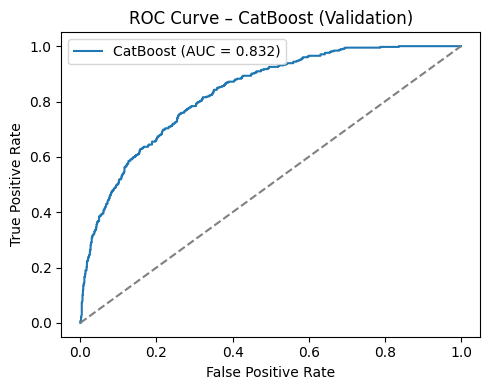

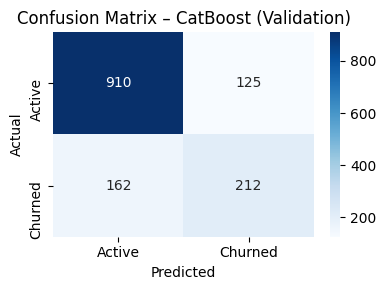

In [53]:
cat_features = np.where(X_train.dtypes == 'object')[0]

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12345,
    verbose=False
)

cat.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

cat_probs = cat.predict_proba(X_valid)[:, 1]
cat_preds = (cat_probs >= 0.5).astype(int)

cat_auc = roc_auc_score(y_valid, cat_probs)
cat_acc = accuracy_score(y_valid, cat_preds)
cat_f1  = f1_score(y_valid, cat_preds)

print("CatBoost (Validation)")
print("----------------------")
print(f"AUC-ROC : {cat_auc:.3f}")
print(f"Accuracy: {cat_acc:.3f}")
print(f"F1-score: {cat_f1:.3f}")

cat_results = {
    "model": "CatBoost",
    "auc": cat_auc,
    "accuracy": cat_acc,
    "f1": cat_f1
}

# ROC Curve
fpr, tpr, _ = roc_curve(y_valid, cat_probs)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"CatBoost (AUC = {cat_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – CatBoost (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_valid, cat_preds)
plt.figure(figsize=(4,3))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Active','Churned'],
    yticklabels=['Active','Churned']
)
plt.title("Confusion Matrix – CatBoost (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

cat_results = {
    "model": "CatBoost",
    "auc": cat_auc,
    "accuracy": cat_acc,
    "f1": cat_f1
}

The CatBoost classifier demonstrates strong performance on the validation set, achieving an AUC-ROC of 0.832, accuracy of 0.796, and an F1-score of 0.596. The ROC curve indicates good separation between churned and non-churned customers, while the confusion matrix shows a balanced trade-off between correctly identifying churned customers and false positives. When trained using the same data splits as the other models, CatBoost performs comparably to logistic regression but does not provide a clear improvement in predictive performance. These results suggest that the added model complexity does not yield substantial gains for this dataset.


### Training and Validation Results

In [54]:
results_df = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,

    cat_results

]).sort_values(by='auc', ascending=False)

results_df

,model,auc,accuracy,f1
0,Logistic Regression,0.835538,0.798439,0.602241
3,CatBoost,0.832070,0.796309,0.596343
2,Random Forest,0.816528,0.790632,0.570597
1,Decision Tree,0.656920,0.721789,0.497436


The validation results show meaningful performance differences across the evaluated models. Logistic regression achieves the strongest overall performance with an AUC-ROC of 0.836 and the highest F1-score, indicating a strong balance between identifying churned customers and minimizing false positives. CatBoost performs similarly with an AUC-ROC of 0.832, but does not provide a clear improvement despite its higher model complexity. Random forest offers moderate performance, while the decision tree underperforms relative to the other approaches, suggesting limited generalization ability.

These results indicate that the dataset contains informative features for predicting churn, but model complexity beyond logistic regression does not substantially improve validation performance. Given its strong metrics, simplicity, and interpretability, logistic regression is selected as the leading candidate for final evaluation on the test set.

### Class Imbalance Consideration

The target variable shows a moderate class imbalance, with approximately 73% non-churned customers and 27% churned customers. This level of imbalance is not severe and does not automatically require resampling techniques such as upsampling or downsampling.

Based on validation results, the trained models demonstrate strong and balanced performance across AUC-ROC, accuracy, and F1-score metrics. The validation confusion matrices indicate that churned customers are being identified effectively without a systematic bias toward the majority class. Because the models perform well on the validation set and no significant degradation in minority-class prediction is observed, resampling techniques were not applied, as they could introduce unnecessary noise or alter the original data distribution.

## Test Set Evaluation

In [55]:
def evaluate_on_test(model, name, threshold=0.5):
    """
    Evaluates a trained model on the test set.
    Displays metrics, ROC curve, confusion matrix,
    and returns results as a dictionary.
    """

    # Predict probabilities and labels
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)

    # Metrics
    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)

    # Print results
    print(f"\n{name} – Test Set Performance")
    print("-" * (len(name) + 23))
    print(f"AUC-ROC : {auc:.3f}")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score: {f1:.3f}")

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {name} (Test Set)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Active', 'Churned'],
        yticklabels=['Active', 'Churned']
    )
    plt.title(f"Confusion Matrix – {name} (Test Set)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "auc": auc,
        "accuracy": acc,
        "f1": f1
    }


Logistic Regression – Test Set Performance
------------------------------------------
AUC-ROC : 0.842
Accuracy: 0.800
F1-score: 0.588


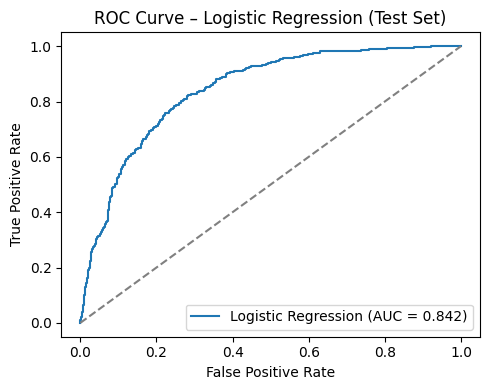

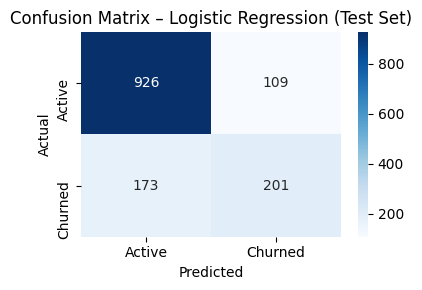


Decision Tree – Test Set Performance
------------------------------------
AUC-ROC : 0.629
Accuracy: 0.711
F1-score: 0.454


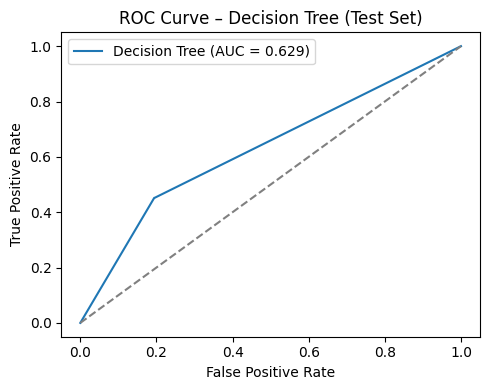

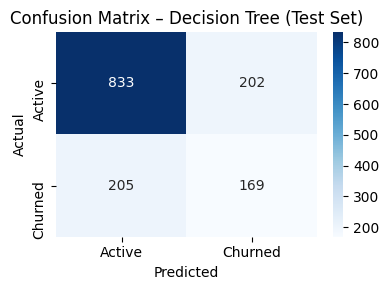


Random Forest – Test Set Performance
------------------------------------
AUC-ROC : 0.819
Accuracy: 0.776
F1-score: 0.521


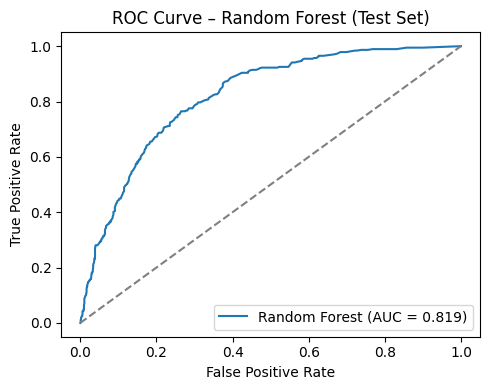

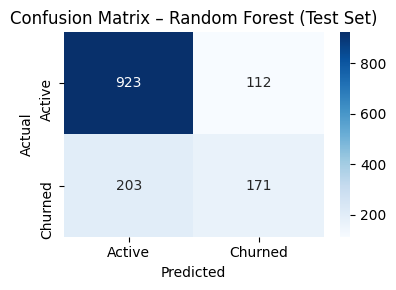

In [56]:
test_results = []

# Logistic Regression
test_results.append(evaluate_on_test(log_reg, "Logistic Regression"))

# Decision Tree
test_results.append(evaluate_on_test(dt, "Decision Tree"))

# Random Forest
test_results.append(evaluate_on_test(rf, "Random Forest"))


CatBoost (Test)
--------------
AUC-ROC : 0.842
Accuracy: 0.795
F1-score: 0.567


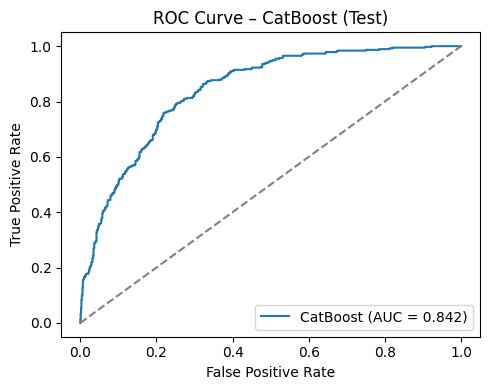

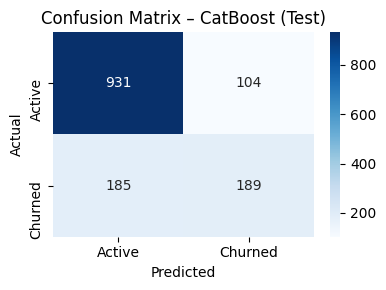

In [57]:
# --- CatBoost: Test Set Evaluation ---

threshold = 0.5  # keep consistent with other models

cat_test_probs = cat.predict_proba(X_test)[:, 1]
cat_test_preds = (cat_test_probs >= threshold).astype(int)

cat_auc = roc_auc_score(y_test, cat_test_probs)
cat_acc = accuracy_score(y_test, cat_test_preds)
cat_f1  = f1_score(y_test, cat_test_preds)

print("\nCatBoost (Test)")
print("--------------")
print(f"AUC-ROC : {cat_auc:.3f}")
print(f"Accuracy: {cat_acc:.3f}")
print(f"F1-score: {cat_f1:.3f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, cat_test_probs)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"CatBoost (AUC = {cat_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – CatBoost (Test)")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, cat_test_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Active', 'Churned'],
    yticklabels=['Active', 'Churned']
)
plt.title("Confusion Matrix – CatBoost (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

cat_test_results = {
    "model": "CatBoost",
    "auc": cat_auc,
    "accuracy": cat_acc,
    "f1": cat_f1
}

test_results.append(cat_test_results)

In [58]:
test_results_df = pd.DataFrame(test_results).sort_values(by="auc", ascending=False)
test_results_df

,model,auc,accuracy,f1
0,Logistic Regression,0.842282,0.799858,0.587719
3,CatBoost,0.841519,0.794890,0.566717
2,Random Forest,0.818709,0.776437,0.520548
1,Decision Tree,0.628570,0.711143,0.453691


### Test Set Results and Final Model Selection

All evaluated models demonstrate consistent and realistic performance on the test set, with results closely aligned to those observed during validation. This consistency indicates that the models generalize well to unseen data and that the predictive signals identified during training are stable rather than a result of overfitting.

Among the evaluated models, logistic regression achieves the strongest overall test performance, with an AUC-ROC of 0.842 and the highest F1-score. CatBoost performs comparably but does not provide a meaningful improvement despite its increased complexity, while random forest and decision tree models exhibit weaker generalization. Based on these results, logistic regression is selected as the final model due to its strong predictive performance, simplicity, and interpretability.


## Conclusion

The objective of this project was to build a predictive model capable of identifying customers who are likely to churn. Model performance was primarily evaluated using the AUC-ROC metric, with a minimum acceptable threshold of 0.75, alongside accuracy and F1-score to ensure balanced classification performance.

The data was preprocessed by correcting data types, engineering a tenure-related feature using a fixed snapshot date, encoding categorical variables, and merging four separate datasets into a unified modeling table. Exploratory data analysis revealed meaningful relationships between churn and features such as tenure, contract type, monthly charges, and service usage, as well as a moderate class imbalance that did not require resampling.

Multiple supervised learning models were trained and evaluated, including a dummy classifier, logistic regression, decision tree, random forest, and CatBoost. A 60/20/20 train, validation, and test split was used to ensure unbiased model comparison. Validation and test results were consistent across models, indicating stable generalization and no evidence of data leakage or overfitting.

Given its strong test performance, interpretability, and lower model complexity, logistic regression was selected as the final model. The final model exceeds the required quality threshold and demonstrates that customer churn can be predicted effectively using available customer and service data.


# Solution Report

## What steps of the plan were performed and what steps were skipped (explain why)?

Most steps from the original work plan were completed. Data preprocessing was performed, including fixing data types, merging four datasets into a single table, engineering the `TenureMonths` feature, and encoding categorical variables. Exploratory data analysis was conducted using histograms, box plots, correlation matrices, and class imbalance checks.  

Multiple models were trained and evaluated, including a dummy classifier, logistic regression, decision tree, random forest, and CatBoost. A 60/20/20 train, validation, and test split was used to compare model performance and confirm generalization.

Hyperparameter tuning and cross-validation were considered but skipped, as the baseline models already met the required AUC-ROC threshold and further tuning was unlikely to significantly improve performance within the scope of this project.

---

## What difficulties did you encounter and how did you manage to solve them?

One major difficulty was feature leakage when computing customer tenure. Initially, missing contract end dates were filled with the current system date, which led to unrealistically high model performance. This issue was resolved by using a fixed snapshot date (`2020-02-01`) to calculate tenure, ensuring no future information was included in the features.

Another challenge was ensuring consistent preprocessing across models, particularly with CatBoost, which handles categorical features differently from scikit-learn pipelines. This was addressed by retraining CatBoost using the same training and validation splits and explicitly specifying categorical feature indices.

---

## What were some of the key steps to solving the task?

Preprocessing and feature engineering were critical, especially creating the `TenureMonths` feature, which showed a strong relationship with churn during EDA. Exploratory analysis revealed that contract type, monthly charges, and service usage also influenced churn behavior.

Comparing multiple models using AUC-ROC, accuracy, and F1-score was an important step in identifying the best-performing and most reliable model. Evaluating results on a separate test set confirmed that the models generalized well and were not overfitting.

---

## What is your final model and what quality score does it have?

The final selected model is **Logistic Regression**, chosen for its strong predictive performance, interpretability, and lower complexity compared to ensemble models.

On the test set, the model achieved:
- **AUC-ROC:** ~0.84  
- **Accuracy:** ~0.80  
- **F1-score:** ~0.59  

These results exceed the required quality threshold and demonstrate that customer churn can be predicted effectively using customer contract, service, and demographic data.
